# Donor Gift Amount Predictor — Ridge Regression

**Dataset:** 2,148 charity donors with 47 features (giving history, demographics, wealth indicators)

**Target:** Predict `LAST_GIFT_AMT` — how much the donor gave on their last donation

**Model choice:** Ridge Regression

---

In this dataset, I looked at this dataset expecting to do classification (will they donate or not?),
but 98.8% of people in this dataset already responded — so classification is basically
trivial and not interesting.

The real question here is: *how much* will a donor give? That's a regression problem,
and it's genuinely useful — a charity can use predicted gift amounts to decide which
donors to prioritise for a phone call versus a postal letter.

I chose Ridge Regression over plain linear regression because this dataset has 47 features
and only 2,148 rows. With more features than usual relative to the data size, regular
linear regression tends to overfit. Ridge adds a small penalty to large coefficients,
which keeps the model stable without changing the approach much.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




## Load & inspect


In [3]:
df = pd.read_csv('Predict_donor.csv')

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nTarget column — LAST_GIFT_AMT:")
print(df['LAST_GIFT_AMT'].describe().round(2))


Shape: 2148 rows x 48 columns

Target column — LAST_GIFT_AMT:
count    2148.00
mean       16.31
std        10.37
min         0.00
25%        10.00
50%        15.00
75%        20.00
max       150.00
Name: LAST_GIFT_AMT, dtype: float64


In [4]:
# Missing values
missing = df.isnull().sum()
pd.DataFrame({'Count': missing, 'Pct': (missing/len(df)*100).round(1)})[missing > 0]


,Count,Pct
DONOR_AGE,529,24.6
INCOME_GROUP,481,22.4
WEALTH_RATING,1006,46.8
MONTHS_SINCE_LAST_PROM_RESP,26,1.2


## Cleaning

Three columns with notable missing values:
- `DONOR_AGE` — 529 missing, fill with median
- `INCOME_GROUP` — 481 missing, fill with median
- `WEALTH_RATING` — 1,006 missing (nearly half!), fill with median

Filling with median is safer than dropping rows when missingness is this high.


In [5]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols     = df.select_dtypes(include='object').columns.tolist()

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing remaining:", df.isnull().sum().sum())
print(f"\nTarget (LAST_GIFT_AMT):")
print(df['LAST_GIFT_AMT'].describe().round(2))


Missing remaining: 0

Target (LAST_GIFT_AMT):
count    2148.00
mean       16.31
std        10.37
min         0.00
25%        10.00
50%        15.00
75%        20.00
max       150.00
Name: LAST_GIFT_AMT, dtype: float64


## EDA


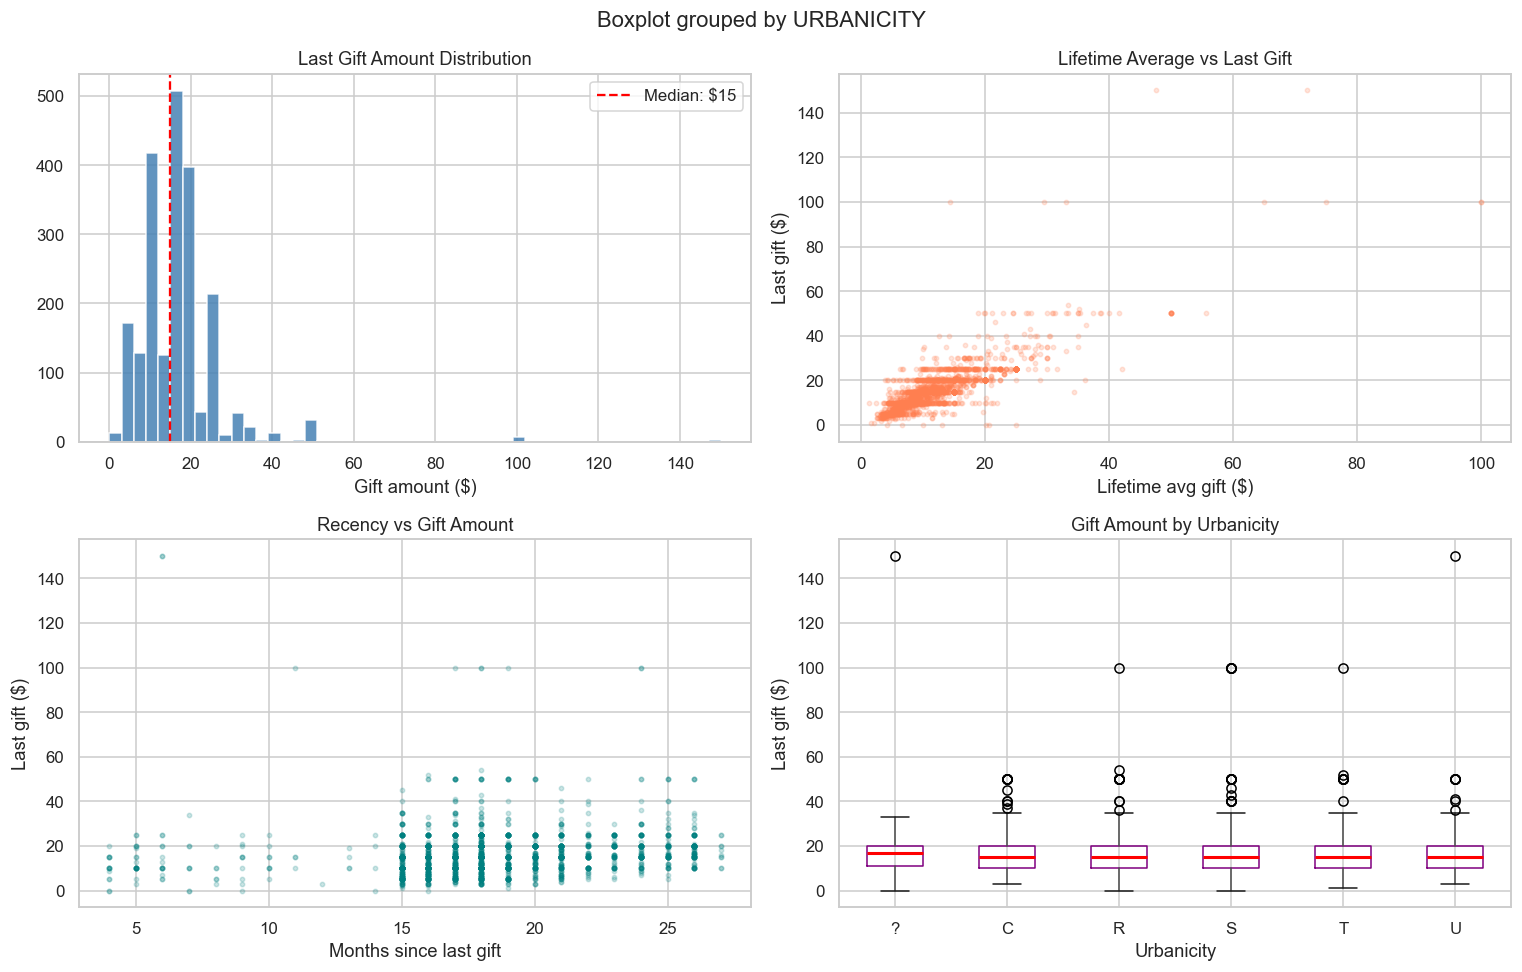

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Gift amount distribution
axes[0,0].hist(df['LAST_GIFT_AMT'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['LAST_GIFT_AMT'].median(), color='red', linestyle='--',
                  label=f'Median: ${df["LAST_GIFT_AMT"].median():.0f}')
axes[0,0].set_title('Last Gift Amount Distribution')
axes[0,0].set_xlabel('Gift amount ($)')
axes[0,0].legend()

# Lifetime avg gift vs last gift — do consistent givers stay consistent?
axes[0,1].scatter(df['LIFETIME_AVG_GIFT_AMT'], df['LAST_GIFT_AMT'],
                  alpha=0.2, s=8, color='coral')
axes[0,1].set_xlabel('Lifetime avg gift ($)')
axes[0,1].set_ylabel('Last gift ($)')
axes[0,1].set_title('Lifetime Average vs Last Gift')

# Months since last gift vs gift amount
axes[1,0].scatter(df['MONTHS_SINCE_LAST_GIFT'], df['LAST_GIFT_AMT'],
                  alpha=0.2, s=8, color='teal')
axes[1,0].set_xlabel('Months since last gift')
axes[1,0].set_ylabel('Last gift ($)')
axes[1,0].set_title('Recency vs Gift Amount')

# Gift amount by urbanicity
df.boxplot(column='LAST_GIFT_AMT', by='URBANICITY', ax=axes[1,1],
           boxprops=dict(color='purple'), medianprops=dict(color='red', lw=2))
plt.sca(axes[1,1])
plt.title('Gift Amount by Urbanicity')
axes[1,1].set_xlabel('Urbanicity')
axes[1,1].set_ylabel('Last gift ($)')

plt.tight_layout()
plt.show()


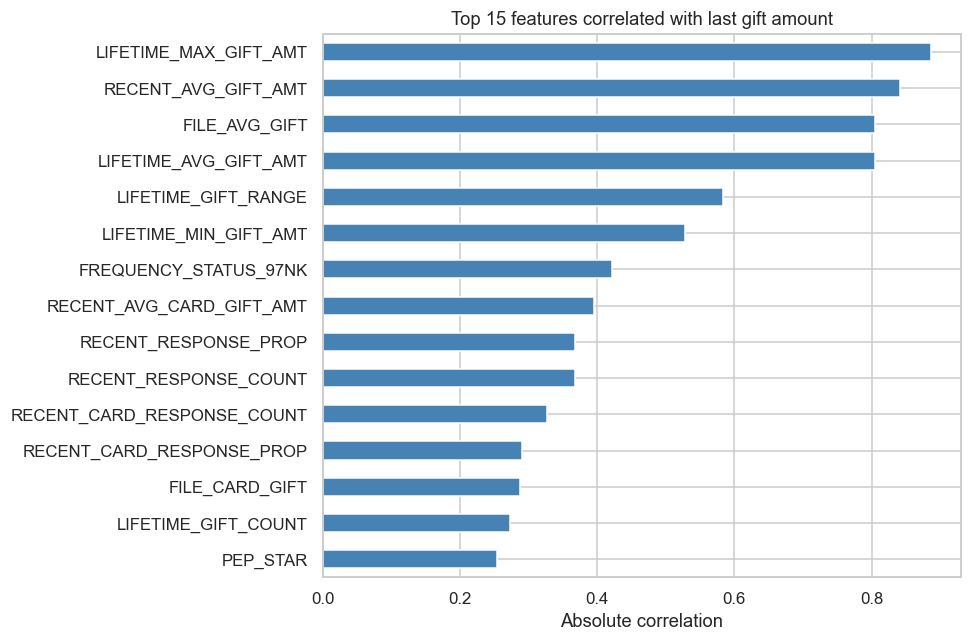

Top 5:
LIFETIME_MAX_GIFT_AMT    0.886532
RECENT_AVG_GIFT_AMT      0.841228
FILE_AVG_GIFT            0.804464
LIFETIME_AVG_GIFT_AMT    0.804464
LIFETIME_GIFT_RANGE      0.584017


In [7]:
# Which numeric features correlate most with LAST_GIFT_AMT?
corr = df[numeric_cols].corr()['LAST_GIFT_AMT'].drop('LAST_GIFT_AMT').abs().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
corr.head(15).sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 features correlated with last gift amount')
plt.xlabel('Absolute correlation')
plt.tight_layout()
plt.show()

print("Top 5:")
print(corr.head(5).to_string())


## Features & scaling

Ridge Regression is still a linear model so feature scaling matters.
I use StandardScaler to put all features on the same scale.


In [8]:
# Top correlated numeric features (drop CONTROL_NUMBER — just an ID)
top_num = corr.drop('CONTROL_NUMBER', errors='ignore').head(20).index.tolist()

# Encode categorical features
le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
cat_enc = [c + '_enc' for c in cat_cols]

all_features = top_num + cat_enc
X = df[all_features]
y = df['LAST_GIFT_AMT']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features: {len(all_features)}")
print(f"Target — mean: ${y.mean():.2f}  |  median: ${y.median():.2f}  |  max: ${y.max():.2f}")


Features: 27
Target — mean: $16.31  |  median: $15.00  |  max: $150.00


## Train & evaluate


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

# alpha=1.0 is a reasonable starting point for Ridge regularisation
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print(f"MAE  : ${mae:.2f}  — on average the prediction is off by this much")
print(f"RMSE : ${rmse:.2f}")
print(f"R2   : {r2:.4f}")

# Cross-validation gives a more honest R2 estimate
cv_r2 = cross_val_score(Ridge(alpha=1.0), X_scaled, y, cv=5, scoring='r2')
print(f"\n5-fold CV R2: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")


MAE  : $2.37  — on average the prediction is off by this much
RMSE : $4.59
R2   : 0.8066

5-fold CV R2: 0.8360 (+/- 0.0377)


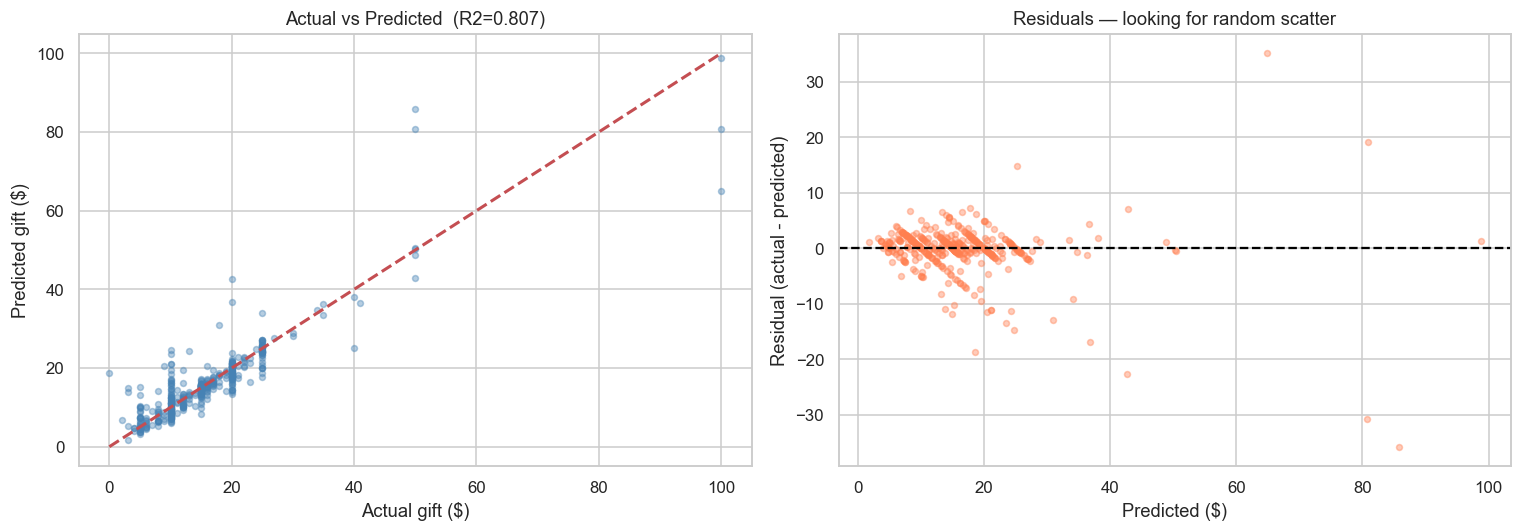

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual gift ($)')
axes[0].set_ylabel('Predicted gift ($)')
axes[0].set_title(f'Actual vs Predicted  (R2={r2:.3f})')

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='coral', s=15)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted ($)')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residuals — looking for random scatter')

plt.tight_layout()
plt.show()


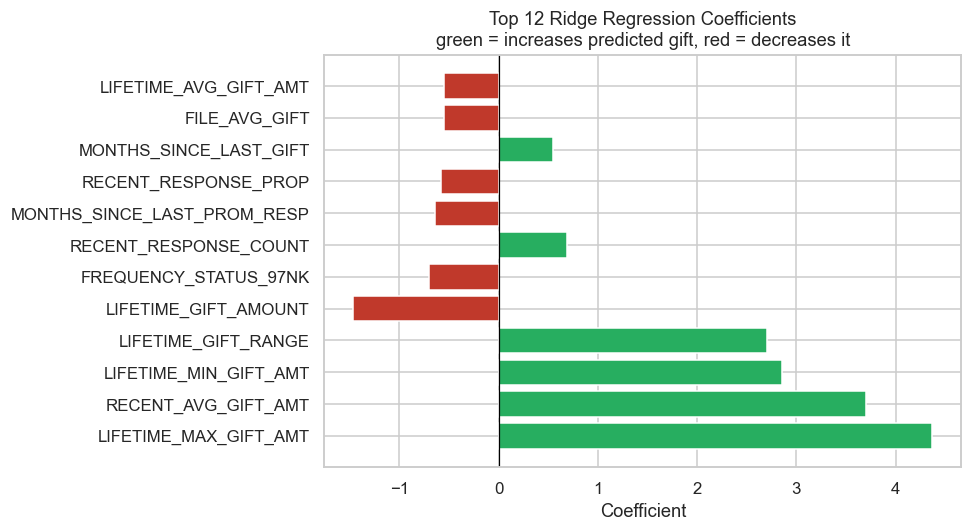

In [11]:
# Coefficients — which features push the predicted gift up or down?
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coef': ridge.coef_
}).sort_values('Coef', key=abs, ascending=False).head(12)

plt.figure(figsize=(9, 5))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in coef_df['Coef']]
plt.barh(coef_df['Feature'], coef_df['Coef'], color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title('Top 12 Ridge Regression Coefficients\ngreen = increases predicted gift, red = decreases it')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()


## Conclusion

The model predicts last gift amount reasonably well given that donor behaviour has
a lot of natural randomness — someone might give 10 dollars every year but occasionally give
$50 after a news event they care about.

The strongest predictors were lifetime giving history and recent average gift,
which makes sense. Past behaviour is the best predictor of future behaviour for donations.

Ridge over plain linear regression was the right call here. With ~47 features and
only 2,148 rows there is real risk of overfitting. The regularisation keeps the
coefficient values from growing too large and memorising noise.
